In [1]:
from pathlib import Path
import os

import numpy as np
from joblib import Parallel, delayed
from sklearn.model_selection import StratifiedShuffleSplit
from treeple import HonestForestClassifier
from treeple.datasets import (make_trunk_classification,
                              make_trunk_mixture_classification)
from sklearn.metrics import roc_auc_score, roc_curve

import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
import string
import matplotlib.lines as mlines

In [2]:
sns.set(font_scale=2)
sns.set_palette("Set1")
colors = sns.color_palette("Set1", n_colors=10, as_cmap=False)

# plt.rcParams['xtick.major.size'] = 20
plt.rcParams["xtick.major.width"] = 3
plt.rcParams["xtick.bottom"] = True
plt.rcParams["ytick.left"] = True



In [3]:
fig5A = pd.read_csv('fig5A.csv')
fig5B = pd.read_csv('fig5B.csv')
fig5C = pd.read_csv('fig5C.csv')
# print(fig5A.head())
# print(fig5A.head())

In [4]:
fontsize = 45
palette = {
    "might": colors[0],
    "rf": colors[1],
    "svm": colors[2],
    "nb": colors[3],
    "lr": colors[4],
}

clf_names = [
    "might",
    "rf",
    "svm",
    "nb",
    "lr",
]

In [5]:
fig5B["Variable-Set Type"] = "empty"
fig5C["Variable-Set Type"] = "empty"
types = [["Wise", "icho"], ["Moti"], ["Dyad"], ["Leng", "Delf"], ["Loci"]]
type_names = [
    "Aneuploidy",
    "Fragment End-Motif",
    "Breakpoint\nAnalysis",
    "Fragment\nLength",
    "Loci\nFraction",
]

for i in range(len(fig5B)):
    for j in range(len(types)):
        if fig5B.iloc[i]["Variable Set"][:4] in types[j]:
            fig5B.iat[i, 6] = type_names[j]


fig5B = fig5B.sort_values(by="Variable-Set Type")


for i in range(len(fig5C)):
    for j in range(len(types)):
        if fig5C.iloc[i]["Variable Set"][:4] in types[j]:
            fig5C.iat[i, 6] = type_names[j]


fig5C = fig5C.sort_values(by="Variable-Set Type")

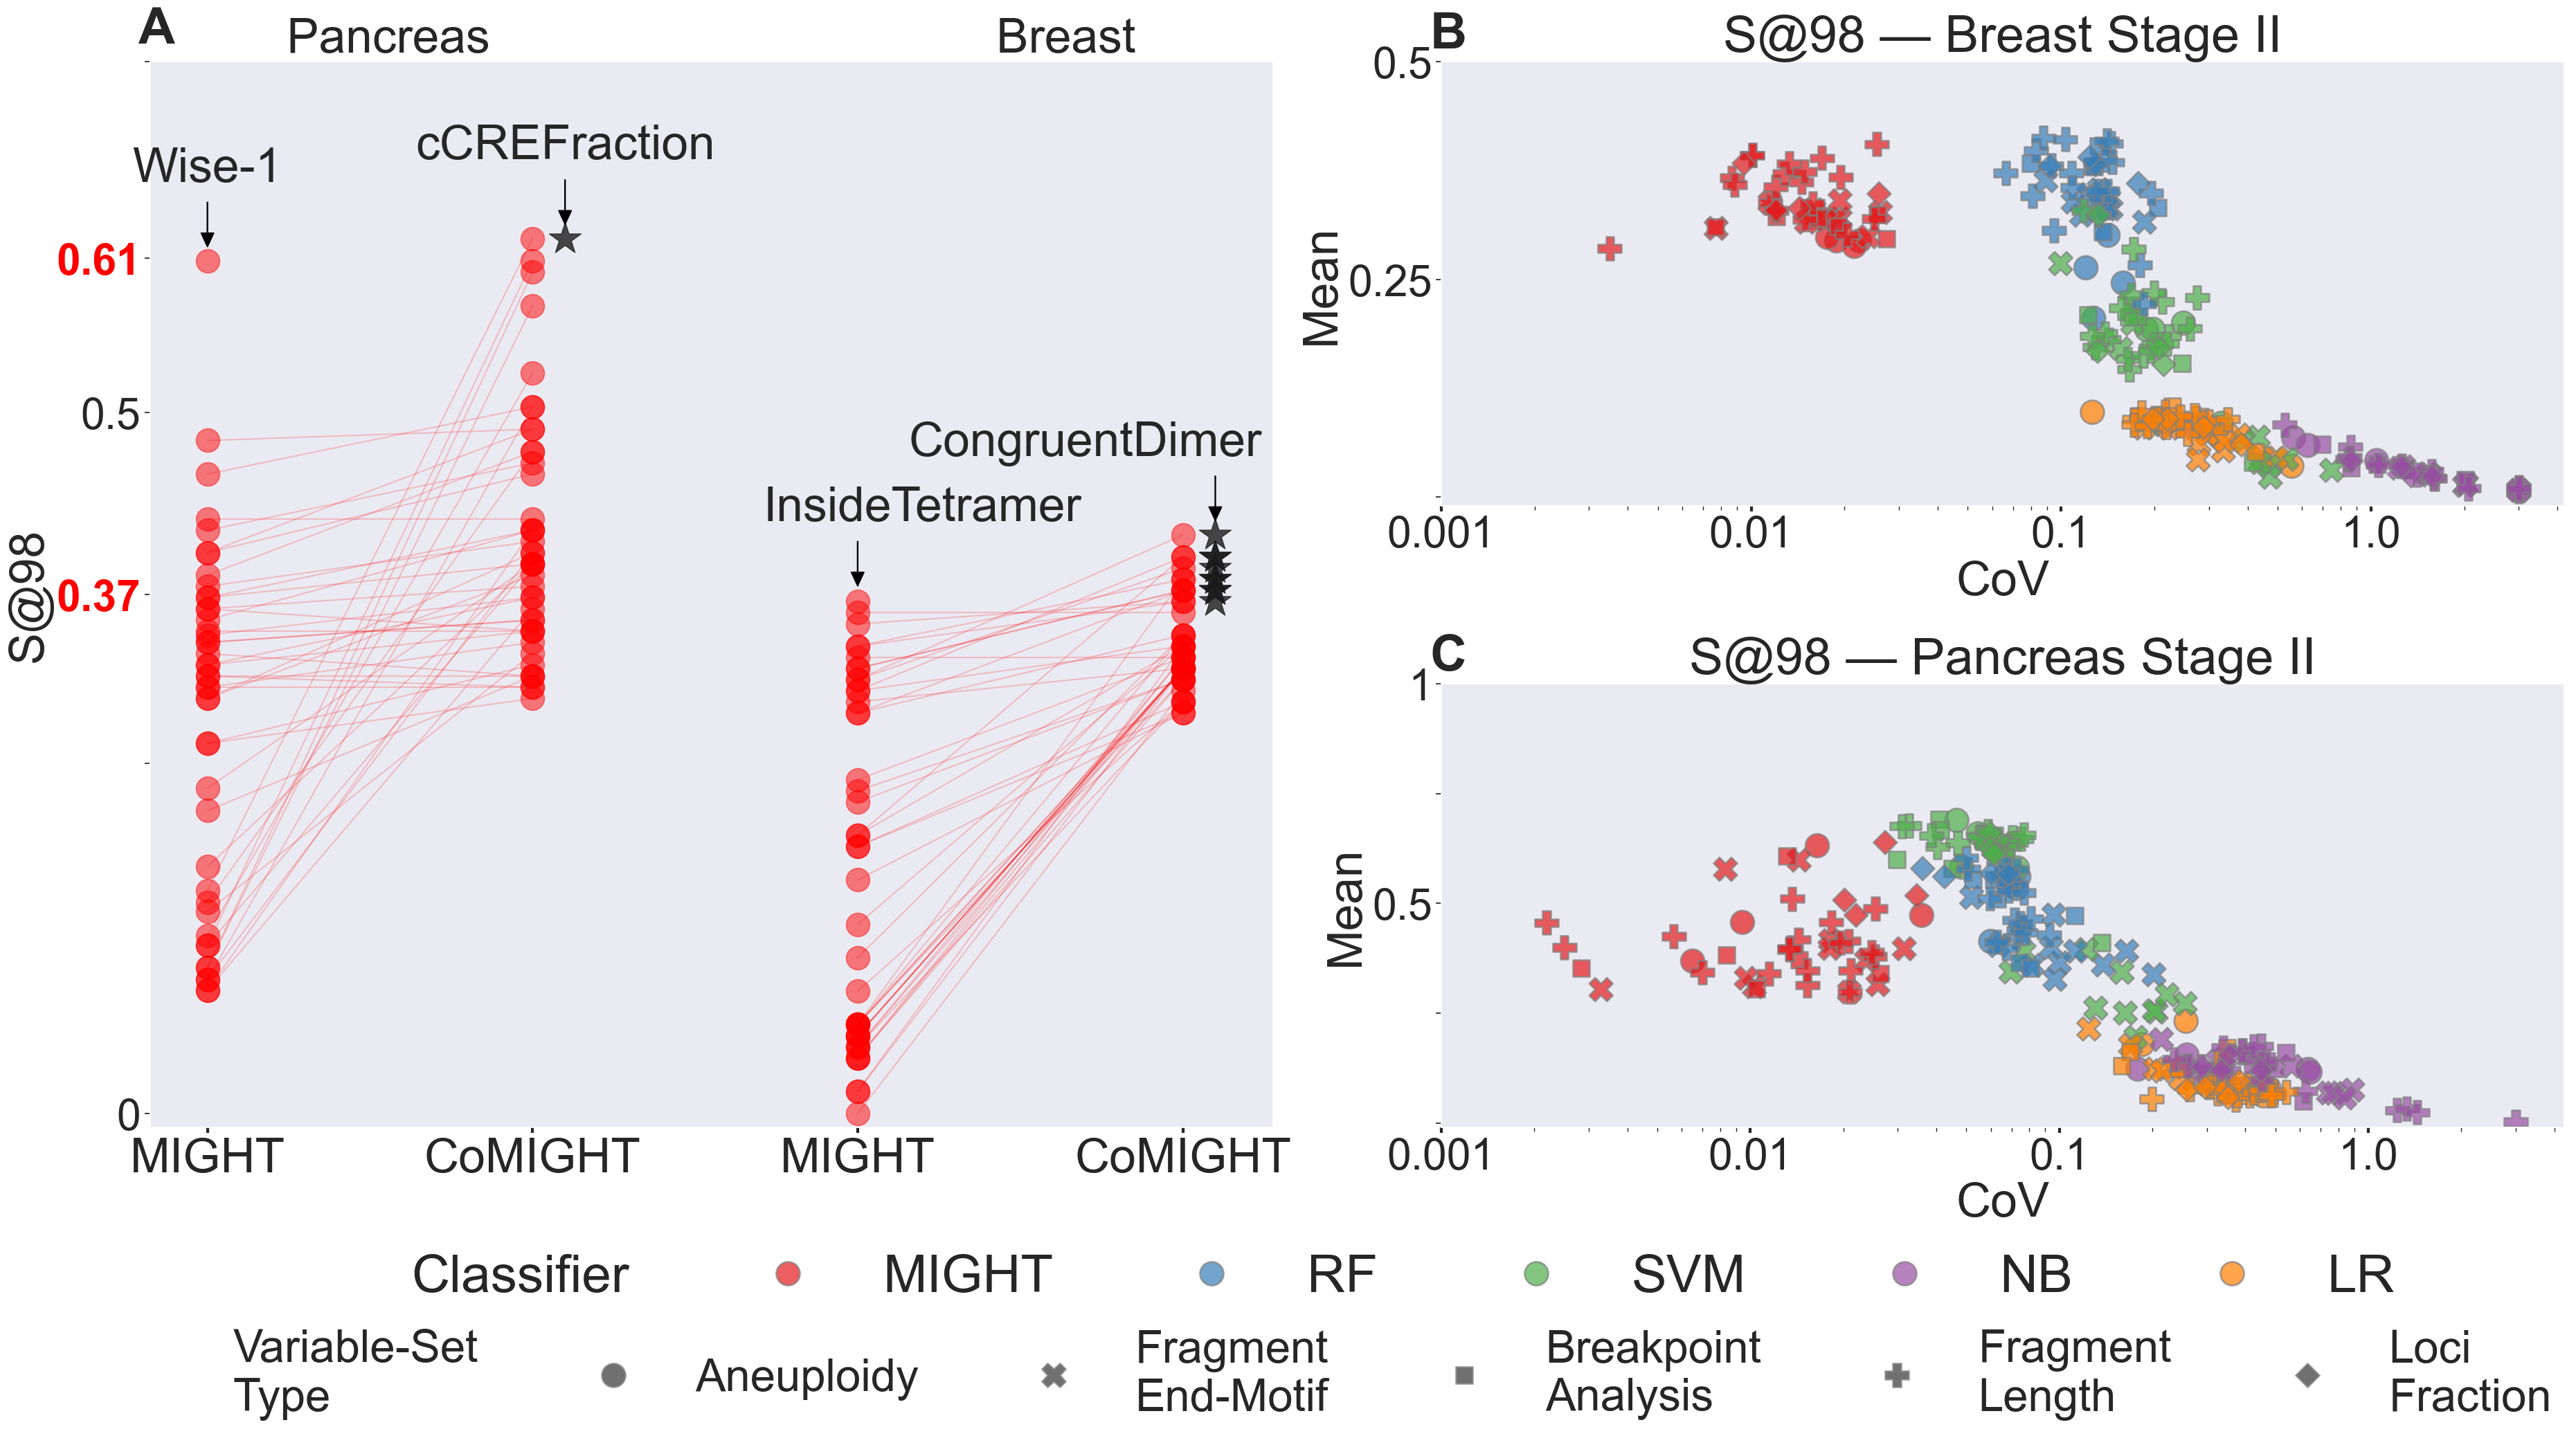

In [12]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# 2:1 width:height makes left subplot (which is half the width and full height) square
fig = plt.figure(figsize=(45, 20))
gs = gridspec.GridSpec(
    2, 2, width_ratios=[1, 1], height_ratios=[1, 1], hspace=0.4, wspace=0.15, figure=fig
)

# Left subplot spans both rows
ax1 = fig.add_subplot(gs[:, 0])

# Top‐right and bottom‐right
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 1])


for ax, letter in zip([ax1, ax2, ax3], ["A", "B", "C"]):
    ax.text(
        -0.01,
        1.008,
        letter,
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=fontsize + 8,
        fontweight="bold",
    )

# --- First (square) plot on ax1 ---
for i, row in fig5A.iterrows():
    # Pancreas in red
    if i == 1:
        ax1.scatter(0.25, row["Pancreas_S98_one"], color="red", s=600, alpha=0.5)
        ax1.scatter(0.75, row["Pancreas_S98_comight_P"], color="red", s=600, alpha=0.5)
        ax1.scatter(
            0.80,
            row["Pancreas_S98_comight_P"],
            color="k",
            s=1200,
            alpha=0.8,
            marker="*",
            edgecolors="k",
        )
        x_mid = 0.90
        y_mid = (
            row["Pancreas_S98_comight_P"] + row["Pancreas_S98_comight_P"]
        ) / 2 + 0.03
        ax1.annotate(
            row["Variable Set"].split(".")[-1],
            (x_mid - 0.1, y_mid + 0.02),
            textcoords="offset points",
            xytext=(0, 10),
            ha="center",
            fontsize=fontsize + 5,
        )
        ax1.arrow(
            x_mid - 0.1,
            y_mid + 0.012,
            0,
            -0.032,
            head_width=0.02,
            head_length=0.01,
            length_includes_head=True,
            color="black",
        )
    elif i != 23:
        ax1.scatter(0.25, row["Pancreas_S98_one"], color="red", s=600, alpha=0.5)
        ax1.scatter(0.75, row["Pancreas_S98_comight_P"], color="red", s=600, alpha=0.5)
    else:
        ax1.scatter(0.25, row["Pancreas_S98_one"], color="red", s=600, alpha=0.5)
    if i == 23:
        x_mid = 0.35
        y_mid = (row["Pancreas_S98_one"] + row["Pancreas_S98_one"]) / 2 + 0.03
        ax1.annotate(
            row["Variable Set"].split(".")[-1],
            (x_mid - 0.1, y_mid + 0.02),
            textcoords="offset points",
            xytext=(0, 10),
            ha="center",
            fontsize=fontsize + 5,
        )
        ax1.arrow(
            x_mid - 0.1,
            y_mid + 0.012,
            0,
            -0.032,
            head_width=0.02,
            head_length=0.01,
            length_includes_head=True,
            color="black",
        )
    else:
        ax1.plot(
            [0.25, 0.75],
            [row["Pancreas_S98_one"], row["Pancreas_S98_comight_P"]],
            color="red",
            alpha=0.2,
        )

    # Breast in blue
    if i in [1, 4, 5, 6, 9, 12, 17, 19, 20]:
        ax1.scatter(1.25, row["Breast_S98_one"], color="red", s=600, alpha=0.5)
        ax1.scatter(1.75, row["Breast_S98_comight_B"], color="red", s=600, alpha=0.5)
        ax1.scatter(
            1.80,
            row["Breast_S98_comight_B"],
            color="k",
            s=1200,
            alpha=0.8,
            marker="*",
            edgecolors="k",
        )
        if i == 4:
            x_mid = 1.90
            y_mid = (
                row["Breast_S98_comight_B"] + row["Breast_S98_comight_B"]
            ) / 2 + 0.03
            ax1.annotate(
                row["Variable Set"].split(".")[-1],
                (x_mid - 0.3, y_mid + 0.02),
                textcoords="offset points",
                xytext=(0, 10),
                ha="center",
                fontsize=fontsize + 5,
            )
            ax1.arrow(
                x_mid - 0.1,
                y_mid + 0.012,
                0,
                -0.032,
                head_width=0.02,
                head_length=0.01,
                length_includes_head=True,
                color="black",
            )
    elif i != 13:
        ax1.scatter(1.25, row["Breast_S98_one"], color="red", s=600, alpha=0.5)
        ax1.scatter(1.75, row["Breast_S98_comight_B"], color="red", s=600, alpha=0.5)
    else:
        ax1.scatter(1.25, row["Breast_S98_one"], color="red", s=600, alpha=0.5)
    if i == 13:
        x_mid = 1.35
        y_mid = (row["Breast_S98_one"] + row["Breast_S98_comight_B"]) / 2 + 0.035
        ax1.annotate(
            row["Variable Set"].split(".")[-1],
            (x_mid, y_mid + 0.02),
            textcoords="offset points",
            xytext=(0, 10),
            ha="center",
            fontsize=fontsize + 5,
        )
        ax1.arrow(
            x_mid - 0.1,
            y_mid + 0.012,
            0,
            -0.032,
            head_width=0.02,
            head_length=0.01,
            length_includes_head=True,
            color="black",
        )
    else:
        ax1.plot(
            [1.25, 1.75],
            [row["Breast_S98_one"], row["Breast_S98_comight_B"]],
            color="red",
            alpha=0.2,
        )

ax1.set_xticks([0.25, 0.75, 1.25, 1.75])
ax1.set_ylim([-0.01, 0.75])
ax1.set_yticks([0, 0.25, 0.37, 0.5, 0.61, 0.75])
ax1.set_yticklabels([0, "", "0.37", "0.5", "0.61", ""], fontsize=fontsize)
for tick in ax1.get_yticklabels():
#     print(tick.get_text())
    if tick.get_text() == "0.37" or tick.get_text() == "0.61":
        tick.set_color("red")
        tick.set_fontweight("bold")

ax1.set_xticklabels(["MIGHT", "CoMIGHT", "MIGHT", "CoMIGHT"], fontsize=fontsize + 5)
ax1.set_title(
    " Pancreas                                      Breast ", fontsize=fontsize + 5
)
ax1.set_ylabel("S@98", fontsize=fontsize + 5)

ax1.grid(False)

sns.scatterplot(
    x="CoV",
    y="mean",
    hue="Classifier",
    data=fig5B,
    s=600,
    alpha=0.7,
    ax=ax2,
    palette=palette,
    legend=False,
    style="Variable-Set Type",
    edgecolor="grey",
    hue_order=clf_names,
)

# y‐axis ticks & labels
ax2.set_ylim(-0.01, 0.5)
ax2.set_yticks([0, 0.25, 0.5])
ax2.set_yticklabels(["", "0.25", "0.5"], fontsize=fontsize)

# log‐scale x
ax2.set_xscale("log")
ticks = [0.001, 0.01, 0.1, 1.0]
ax2.set_xticks(ticks)
ax2.set_xticklabels([str(t) for t in ticks], fontsize=fontsize)

# labels & title
ax2.set_xlabel("CoV", fontsize=fontsize + 5)
ax2.set_ylabel("Mean", fontsize=fontsize + 5)
ax2.set_title("S@98 — Breast Stage II", fontsize=fontsize + 8)

ax2.grid(False)

# --- Example: third plot on ax3 (replace with your own code) ---
sns.scatterplot(
    x="CoV",
    y="mean",
    hue="Classifier",
    data=fig5C,
    s=600,
    alpha=0.7,
    ax=ax3,
    palette=palette,
    style="Variable-Set Type",
    edgecolor="grey",
    hue_order=clf_names,
)

# y‐axis ticks & labels
ax3.set_ylim(-0.01, 1.0)
ax3.set_yticks([0, 0.25, 0.5, 0.75, 1])
ax3.set_yticklabels(["", "", "0.5", "", "1"], fontsize=fontsize)

# log‐scale x
ax3.set_xscale("log")
ticks = [0.001, 0.01, 0.1, 1.0]
ax3.set_xticks(ticks)
ax3.set_xticklabels([str(t) for t in ticks], fontsize=fontsize)

# labels & title
ax3.set_xlabel("CoV", fontsize=fontsize + 5)
ax3.set_ylabel("Mean", fontsize=fontsize + 5)
ax3.set_title("S@98 — Pancreas Stage II", fontsize=fontsize + 8)

ax3.grid(False)

# custom legend order & labels
# legend_labels = {"rf": "RF", "svm": "SVM", "might": "MIGHT", "nb": "NB", "lr": "LR"}
# desired_order = ["might", "rf", "svm", "nb", "lr"]
# handles, labels = ax3.get_legend_handles_labels()
# legend_dict = dict(zip(labels, handles))
# reordered = [legend_dict[l] for l in desired_order if l in legend_dict]
# new_labels = [legend_labels[l] for l in desired_order]
# ax3.legend(
#     reordered,
#     new_labels,
#     loc="center",
#     bbox_to_anchor=(-0.2, -0.3),
#     ncol=len(new_labels),
#     frameon=False,
#     fontsize=fontsize + 5,
# )
handles, labels = ax3.get_legend_handles_labels()
hue_labels = fig5C["Classifier"].dropna().unique()
style_labels = fig5C["Variable-Set Type"].dropna().unique()

hue_handles = handles[: len(hue_labels)+1]
hue_names = labels[: len(hue_labels)+1]
hue_names = [hue_names[0], "MIGHT"] + [word.upper() for word in hue_names[2:]]

style_handles = handles[len(hue_labels) +1:]
style_names = [
    "Variable-Set\nType",
    "Aneuploidy",
    "Fragment\nEnd-Motif",
    "Breakpoint\nAnalysis",
    "Fragment\nLength",
    "Loci\nFraction",
]

legend1 = ax3.legend(
    handles=hue_handles,
    labels=hue_names,
    loc="lower center",
    bbox_to_anchor=(-0.1, -0.5),
    frameon=False,
    ncol=len(hue_names),
    fontsize=fontsize+10,
)

# Second legend (sex/style)
legend2 = ax3.legend(
    handles=style_handles,
    labels=style_names,  # title='Variable-Set Type',
    loc="lower center",
    bbox_to_anchor=(-0.1, -0.75),
    frameon=False,
    ncol=len(style_names),
    fontsize=fontsize+2,
)

# Add back the first legend manually
ax3.add_artist(legend1)
plt.show()